# Prédiction de survie des passagers du Titanic
# Objectif
Construire un modèle de classification capable de prédire la probabilité de survie d'un passager.
# Problématique
Quels facteurs influencent significativement la surive?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Analyse exploratoire des données (EDA)
Nous explorons la structure du dataset afin d'identifier :
- les types des variables,
- les valeurs manquantes,
- les distributions,
- les premières tendances.

In [2]:
df= pd.read_csv("../data/raw/titanic.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

On observe que certaines variables (Age, Cabin, Embarked) contiennent des valeurs manquantes.
Ces valeurs devront être traités avant la modélisation.

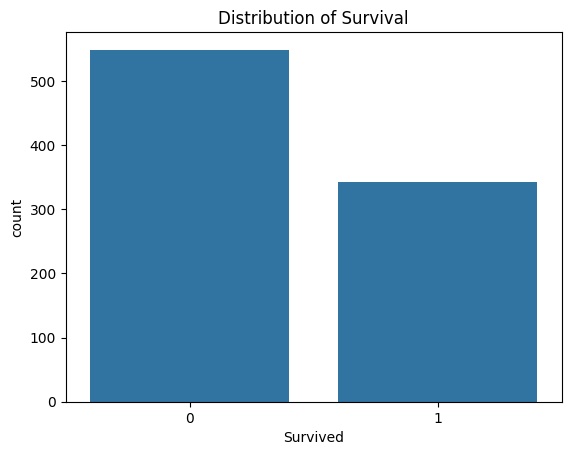

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Survived", data=df)
plt.title("Distribution of Survival")
plt.show()

Grâce à ce graphique, on remarque que le nombre de passagers décédés est supérieur au nombre de survivants. Le dataset est donc légèrement déséquilibré.

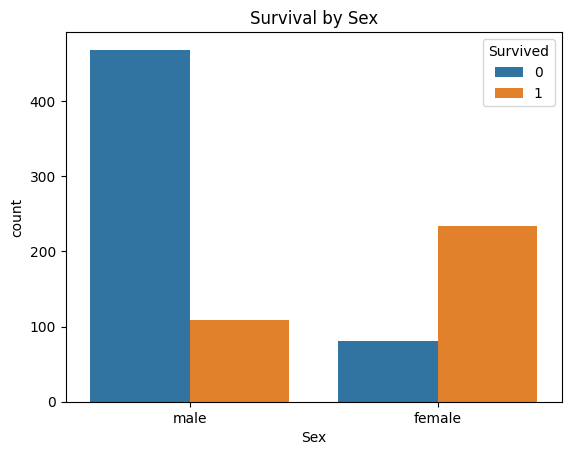

In [5]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Sex")
plt.show()

Les hommes présentent un taux de survie relativement faible comparé aux femmes. Celà pourrait s'expliquer par la priorité donnée aux femmes lors de l'évacuation.

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


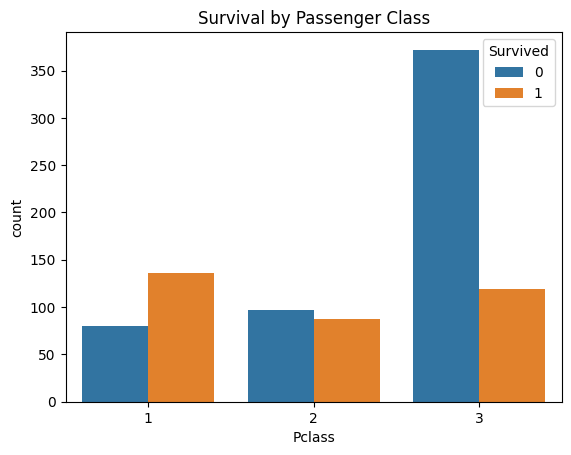

In [6]:
survival_rate_by_class = df.groupby("Pclass")["Survived"].mean()
print(survival_rate_by_class)
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

Le cacul du taux de survie montre une différence significative entre les classes.Les passagers de la classe 3 sont ceux qui ont subis le maximum de perte en vies humaines. Cela peut s'expliquer par le fait qu'ils étaient beaucoup plus nombreux sur le bateau que les autres classes. Cependant, les passagers de la classe 1 semblent présenter un taux de survie beaucoup plus élevé, ce qui suggère aussi un impact potentiel du statut socio-économique sur les chances de survie.

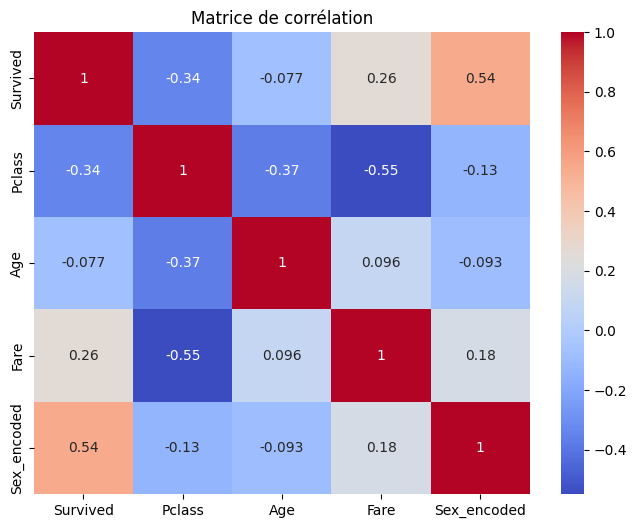

In [7]:
# Création d'une copie pour l'analyse
df_corr = df.copy()

# Encodage de la variable Sex
df_corr["Sex_encoded"] = df_corr["Sex"].map({"male" : 0, "female" : 1})

# Matrice de corrélation
plt.figure(figsize = (8,6))
sns.heatmap(df_corr[["Survived", "Pclass", "Age", "Fare", "Sex_encoded"]].corr(), annot = True, cmap = "coolwarm")
plt.title("Matrice de corrélation")
plt.show()


Après encodage de la variable Sex , on observe une forte corrélation positive entre le fait d'être une femme et la probabilité de survie.
Celà confirme l'importante du critère : "Women and children first" lors de l'évacuation.

# Préparation des données nécessaires à la modélisation
Avant d'entrainer le modèle, plusieurs éétapes sont nécessaires :
- Encodage de la variable Sex
- Imputation des valeurs manquantes
- Sélection des variables explicatives
Ces étapes permettent que les données soient exploitables par l'algorythme.

In [8]:
# Préparation des données pour la modélisation
df_model = df.copy()

# Encodage de Sex
df_model["Sex"] = df_model["Sex"].map({"male" : 0, "female" : 1})

# Gestion des valeurs manquantes 
df_model["Age"] = df_model["Age"].fillna(df_model["Age"].median())
df_model["Fare"] = df_model["Fare"].fillna(df_model["Fare"].median())

# Définition des variables
X = df_model[["Pclass", "Age", "Fare", "Sex"]]
y = df_model["Survived"]


# Modélisation
Nous utilsons une régression logistique pour prédire la survie des passagers.
La régression logistique est adaptée aux problèmes de classification binéaire, comme ici où la variable cible (Survived) prend les valeurs 0 et 1.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy : ", accuracy_score(y_test, y_pred))

Accuracy :  0.8044692737430168


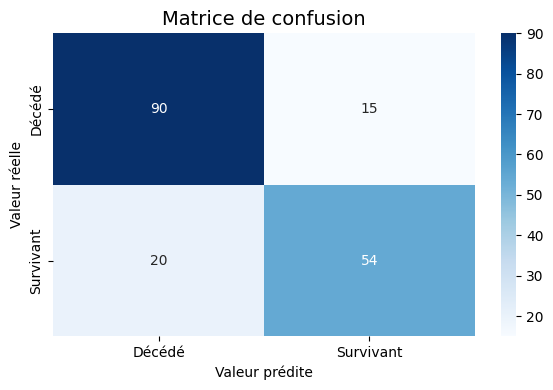

              precision    recall  f1-score   support

      Décédé       0.82      0.86      0.84       105
   Survivant       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Décédé", "Survivant"],
            yticklabels=["Décédé", "Survivant"])
plt.title("Matrice de confusion", fontsize=14)
plt.ylabel("Valeur réelle")
plt.xlabel("Valeur prédite")
plt.tight_layout()
plt.show()

# Rapport de classification
print(classification_report(y_test, y_pred, 
      target_names=["Décédé", "Survivant"]))

## Matrice de confusion

Le modèle prédit correctement 90 décès et 54 survies.
Les principales erreurs sont :
- 15 faux positifs (décédés prédits survivants)
- 20 faux négatifs (survivants prédits décédés)

Le modèle est légèrement meilleur pour prédire les décès 
que les survies, ce qui peut s'expliquer par le léger 
déséquilibre du dataset (plus de décédés que de survivants).

Accuracy Random Forest : 0.7933
Accuracy Régression Logistique : 0.8045


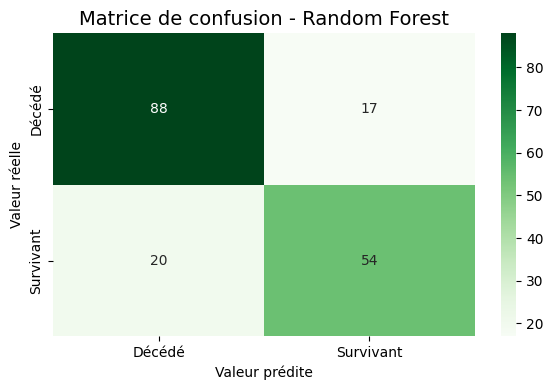

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Modèle Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy Random Forest : {round(rf_accuracy, 4)}")
print(f"Accuracy Régression Logistique : {round(accuracy_score(y_test, y_pred), 4)}")

# Matrice de confusion Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Décédé", "Survivant"],
            yticklabels=["Décédé", "Survivant"])
plt.title("Matrice de confusion - Random Forest", fontsize=14)
plt.ylabel("Valeur réelle")
plt.xlabel("Valeur prédite")
plt.tight_layout()
plt.show()

## Comparaison des modèles

| Modèle | Accuracy |
|---|---|
| Régression Logistique | 80.4% |
| Random Forest | 79.3% |

Les deux modèles obtiennent des performances similaires.
La régression logistique reste légèrement meilleure sur 
ce dataset, ce qui suggère que les relations entre les 
variables sont majoritairement linéaires.

Le Random Forest pourrait être amélioré avec une 
optimisation des hyperparamètres (GridSearchCV).

In [12]:
from sklearn.model_selection import GridSearchCV

# Grille des hyperparamètres à tester
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

# GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleure accuracy (CV) :", round(grid_search.best_score_, 4))

# Évaluation sur le test
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Accuracy sur test :", round(accuracy_score(y_test, y_pred_best), 4))

Meilleurs paramètres : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Meilleure accuracy (CV) : 0.8371
Accuracy sur test : 0.8212


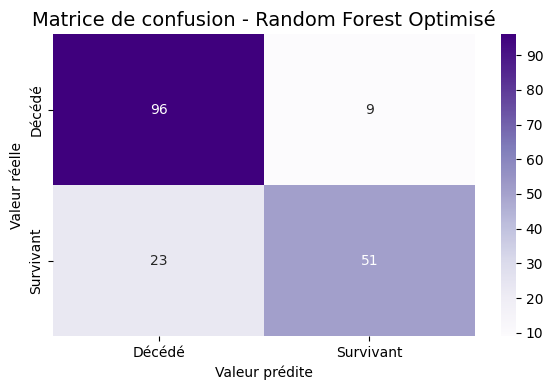

In [13]:
cm_best = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Décédé", "Survivant"],
            yticklabels=["Décédé", "Survivant"])
plt.title("Matrice de confusion - Random Forest Optimisé", fontsize=14)
plt.ylabel("Valeur réelle")
plt.xlabel("Valeur prédite")
plt.tight_layout()
plt.show()

# Conclusion

Ce projet de prédiction de survie sur le Titanic a permis 
de construire et comparer plusieurs modèles de classification.

**Principaux enseignements :**
- Le sexe et la classe sociale sont les facteurs les plus 
  déterminants pour la survie
- Le Random Forest optimisé avec GridSearchCV atteint 
  82.1% d'accuracy, soit +2% vs la régression logistique
- L'optimisation des hyperparamètres améliore 
  significativement la détection des décès (96 vs 88)

**Pistes d'amélioration :**
- Feature engineering (titre des passagers, taille famille)
- XGBoost ou LightGBM pour aller plus loin
- Traitement plus fin des valeurs manquantes

In [14]:
# 1. Extraction du titre depuis le nom
df_model["Title"] = df["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(df_model["Title"].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [15]:
# 2. Regroupement des titres rares
df_model["Title"] = df_model["Title"].replace(
    ["Dr", "Rev", "Major", "Col", "Capt"], "Officer"
)
df_model["Title"] = df_model["Title"].replace(
    ["Mlle", "Mme", "Ms", "Lady", "Sir", "Don", "Countess", "Jonkheer"], "Rare"
)

print(df_model["Title"].value_counts())

# 3. Encodage du titre
df_model["Title_encoded"] = df_model["Title"].map({
    "Mr": 0, "Miss": 1, "Mrs": 2, 
    "Master": 3, "Officer": 4, "Rare": 5
})

# 4. Taille de la famille
df_model["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# 5. Passager seul
df_model["IsAlone"] = (df_model["FamilySize"] == 1).astype(int)

print(df_model[["Title", "FamilySize", "IsAlone"]].head(10))

Title
Mr         517
Miss       182
Mrs        125
Master      40
Officer     18
Rare         9
Name: count, dtype: int64
    Title  FamilySize  IsAlone
0      Mr           2        0
1     Mrs           2        0
2    Miss           1        1
3     Mrs           2        0
4      Mr           1        1
5      Mr           1        1
6      Mr           1        1
7  Master           5        0
8     Mrs           3        0
9     Mrs           2        0


In [16]:
# Nouvelles variables explicatives
X_new = df_model[["Pclass", "Age", "Fare", "Sex", 
                   "Title_encoded", "FamilySize", "IsAlone"]]
y_new = df_model["Survived"]

# Split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

# Random Forest optimisé avec nouvelles features
best_model_new = RandomForestClassifier(
    n_estimators=300, max_depth=10, 
    min_samples_split=10, random_state=42
)
best_model_new.fit(X_train_new, y_train_new)
y_pred_new = best_model_new.predict(X_test_new)

print("Accuracy avec feature engineering :", 
      round(accuracy_score(y_test_new, y_pred_new), 4))
print("Accuracy sans feature engineering : 0.8212")

Accuracy avec feature engineering : 0.8268
Accuracy sans feature engineering : 0.8212


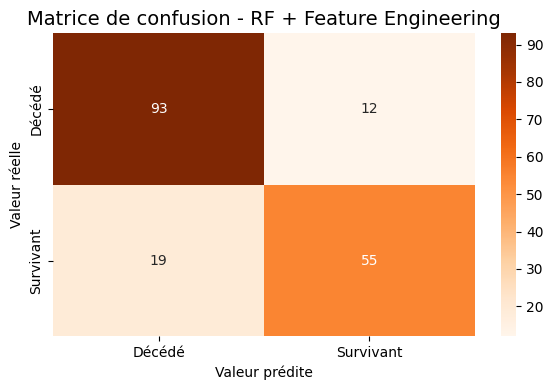

In [17]:
cm_new = confusion_matrix(y_test_new, y_pred_new)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_new, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Décédé", "Survivant"],
            yticklabels=["Décédé", "Survivant"])
plt.title("Matrice de confusion - RF + Feature Engineering", fontsize=14)
plt.ylabel("Valeur réelle")
plt.xlabel("Valeur prédite")
plt.tight_layout()
plt.show()

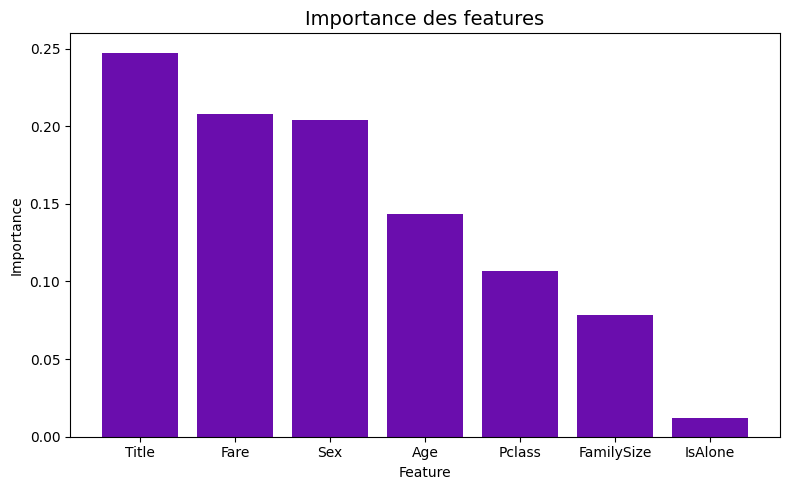

In [18]:
# Importance des features
importances = best_model_new.feature_importances_
features = ["Pclass", "Age", "Fare", "Sex", 
            "Title", "FamilySize", "IsAlone"]

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(feat_df["Feature"], feat_df["Importance"], color="#6A0DAD")
plt.title("Importance des features", fontsize=14)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## Importance des features

Le titre du passager (extrait du nom) est la variable 
la plus prédictive avec 25% d'importance. Cela confirme 
que le statut social et le genre encodés dans le titre 
("Mr", "Mrs", "Master"...) sont des facteurs clés de survie.

Le prix du billet (Fare) et le sexe arrivent en 2ème 
et 3ème position, confirmant l'impact du statut 
socio-économique et du critère "Women and children first".


## Conclusion générale

Ce projet de prédiction de survie sur le Titanic a permis 
de construire et d'améliorer progressivement un modèle 
de classification en suivant une démarche rigoureuse.

### Récapitulatif des performances

| Modèle | Accuracy |
|---|---|
| Régression Logistique | 80.4% |
| Random Forest de base | 80.0% |
| Random Forest + GridSearchCV | 82.1% |
| Random Forest + Feature Engineering | 82.7% |

### Enseignements clés
- Le titre du passager (extrait du nom) est la variable 
  la plus prédictive, une preuve de l'importance 
  du feature engineering
- Le sexe et le statut socio-économique sont des facteurs 
  déterminants de survie
- L'optimisation des hyperparamètres et le feature 
  engineering ont permis d'améliorer l'accuracy de +2.3%

### Pistes d'amélioration
- Tester XGBoost ou LightGBM
- Appliquer une validation croisée plus robuste
- Explorer d'autres features (deck de la cabine, 
  port d'embarquement)